In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Menampilkan 5 data teratas
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()
print("\njumlah data yang kosong:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Mengubah kolom Churn jadi angka (Yes=1, No=0)
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Mengubah kolom gender jadi angka (Male=1, Female=0)
df['gender'] = df['gender'].apply(lambda x: 1 if x == 'Male' else 0)

# Menampilkan hasil perubahan
df[['gender', 'Churn']].head()


,gender,Churn
0,0,0
1,1,0
2,1,1
3,1,0
4,0,1


In [5]:
# Mengubah semua kolom teks tersisa menjadi angka secara otomatis
df_final = pd.get_dummies(df)

# Menampilkan hasil akhir
df_final.head()


,gender,SeniorCitizen,tenure,MonthlyCharges,Churn,customerID_0002-ORFBO,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,...,TotalCharges_995.35,TotalCharges_996.45,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9
0,0,0,1,29.85,0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1,0,34,56.95,0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,0,2,53.85,1,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,0,45,42.30,0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0,0,2,70.70,1,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [6]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Hapus customerID (Wajib karena ini bukan fitur prediksi)
df.drop('customerID', axis=1, inplace=True)

# Ubah TotalCharges jadi angka dan isi yang kosong dengan 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Ubah Churn & gender jadi angka sederhana
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)
df['gender'] = df['gender'].apply(lambda x: 1 if x == 'Male' else 0)

# jalankan get_dummies untuk sisa kolom teks
df_final = pd.get_dummies(df)

print("Jumlah kolom sekarang:", df_final.shape[1])
df_final.head()


Jumlah kolom sekarang: 45


,gender,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,29.85,29.85,0,False,True,True,False,...,False,True,False,False,False,True,False,False,True,False
1,1,0,34,56.95,1889.50,0,True,False,True,False,...,False,False,True,False,True,False,False,False,False,True
2,1,0,2,53.85,108.15,1,True,False,True,False,...,False,True,False,False,False,True,False,False,False,True
3,1,0,45,42.30,1840.75,0,True,False,True,False,...,False,False,True,False,True,False,True,False,False,False
4,0,0,2,70.70,151.65,1,True,False,True,False,...,False,True,False,False,False,True,False,False,True,False


X (Fitur): Semua kolom kecuali target (Churn).
y (Target): Kolom Churn (yang ingin diprediksi).

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Pisahkan Target (y) dan Fitur (X)
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

# 2. Bagi menjadi data Latih (80%) dan data Uji (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Buat Model AI (Random Forest)
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 4. Latih AI dengan data latih
model.fit(X_train, y_train)

# 5. Minta AI menebak data uji
y_pred = model.predict(X_test)

# 6. Lihat seberapa pintar AI kita
print("Akurasi Model: ", accuracy_score(y_test, y_pred))
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred))


Akurasi Model:  0.7927608232789212

Laporan Klasifikasi:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.65      0.47      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



Visualisasi

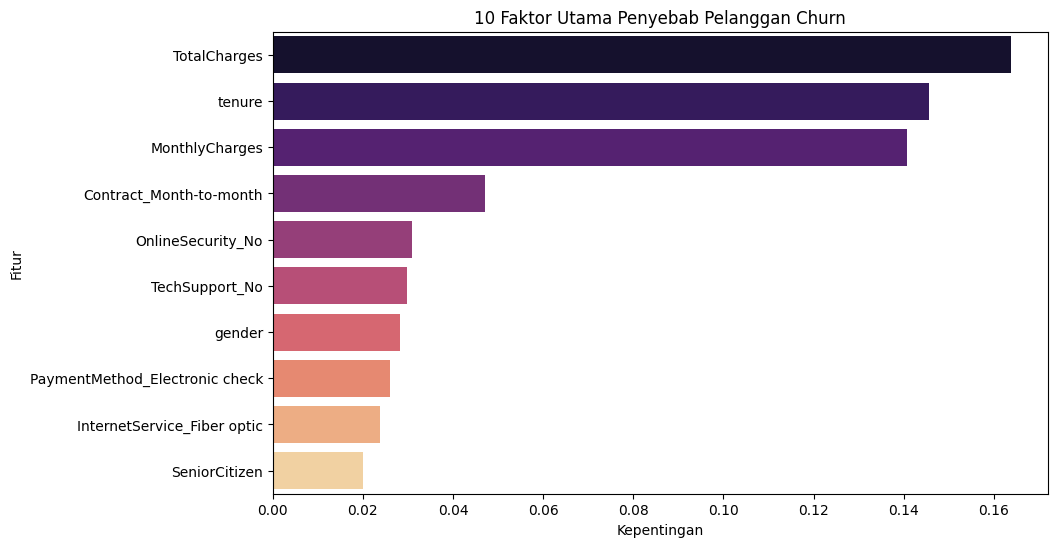

In [8]:
import seaborn as sns  
import matplotlib.pyplot as plt


importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Fitur': feature_names, 'Kepentingan': importances})
feature_importance_df = feature_importance_df.sort_values(by='Kepentingan', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Kepentingan', y='Fitur', data=feature_importance_df, hue='Fitur', palette='magma', legend=False)
plt.title('10 Faktor Utama Penyebab Pelanggan Churn')
plt.show()
